<a href="https://colab.research.google.com/github/nauliaimtk02/Proyek-EAS-Pengantar-Proses-Stokastik/blob/main/EAS_Prostok_Aulia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : Nur Aulia Imtinan

NIM : 2430209040007

MATA KULIAH : Pengantar Proses Stokastik


--- Matriks Probabilitas Transisi ---
        Lancar  Padat  Macet
Lancar     0.6    0.3    0.1
Padat      0.3    0.5    0.2
Macet      0.3    0.3    0.4

--- Simulasi Rantai Markov (Model Kondisi Lalu Lintas) ---
Memulai simulasi dari keadaan: Lancar
Riwayat simulasi 1000 langkah:['Lancar', 'Padat', 'Lancar', 'Padat', 'Macet', 'Padat', 'Lancar', 'Padat', 'Padat', 'Padat', 'Lancar', 'Padat', 'Padat', 'Lancar', 'Padat', 'Macet', 'Padat', 'Lancar', 'Macet', 'Padat', 'Lancar', 'Lancar', 'Padat', 'Lancar', 'Lancar', 'Lancar', 'Lancar', 'Lancar', 'Lancar', 'Lancar', 'Padat', 'Lancar', 'Padat', 'Padat', 'Padat', 'Macet', 'Padat', 'Padat', 'Lancar', 'Lancar', 'Padat', 'Lancar', 'Padat', 'Padat', 'Lancar', 'Lancar', 'Padat', 'Lancar', 'Lancar', 'Macet', 'Macet', 'Padat', 'Padat', 'Lancar', 'Lancar', 'Lancar', 'Macet', 'Macet', 'Macet', 'Padat', 'Lancar', 'Padat', 'Padat', 'Lancar', 'Padat', 'Padat', 'Lancar', 'Macet', 'Lancar', 'Padat', 'Macet', 'Lancar', 'Macet', 'Macet', 'Lancar', 'Lancar',

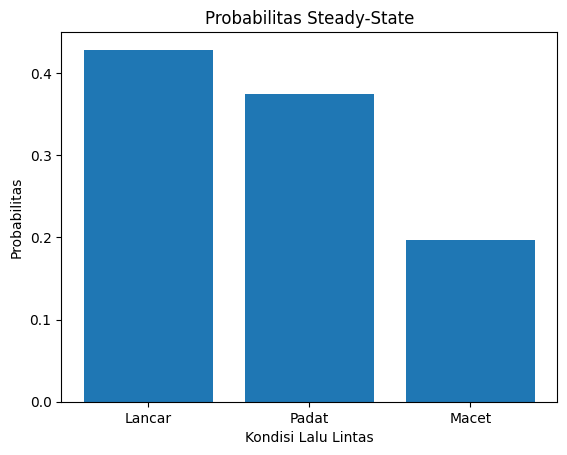

In [3]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

class MarkovChain:

    def __init__(self, states, transition_matrix):

        self.states = states
        self.transition_matrix = np.array(transition_matrix)
        self.num_states = len(states)

        # Validasi ukuran matriks
        if self.transition_matrix.shape != (self.num_states, self.num_states):
            raise ValueError("Ukuran matriks transisi tidak sesuai dengan jumlah status.")

        # Validasi jumlah probabilitas tiap baris = 1
        if not np.allclose(self.transition_matrix.sum(axis=1), 1.0):
            raise ValueError("Jumlah probabilitas tiap baris dalam matriks transisi harus 1.")

        self.state_to_index = {state: i for i, state in enumerate(states)}
        self.index_to_state = {i: state for i, state in enumerate(states)}

    # Menentukan state berikutnya
    def get_next_state(self, current_state):

        current_index = self.state_to_index[current_state]
        probabilities = self.transition_matrix[current_index]
        next_index = random.choices(range(self.num_states),weights=probabilities,k=1)[0]
        return self.index_to_state[next_index]

    # Simulasi rantai Markov
    def simulate(self, initial_state, num_steps):

        current_state = initial_state
        history = [current_state]
        print(f"Memulai simulasi dari keadaan: {initial_state}")

        for _ in range(num_steps):
            next_state = self.get_next_state(current_state)
            history.append(next_state)
            current_state = next_state
        return history

    # Menghitung steady-state
    def calculate_steady_state(self):

        A = self.transition_matrix.T - np.identity(self.num_states)

        A[-1,:] = 1
        b = np.zeros(self.num_states)
        b[-1] = 1

        # Selesaikan sistem linear
        steady_state_probabilities = np.linalg.solve(A, b)
        return dict(zip(self.states, steady_state_probabilities))


# ======= MENENTUKAN STATE =======
# Model Kondisi Lalu Lintas
states = ["Lancar", "Padat", "Macet"]

# Matriks Transisi P (P_ij = probabilitas transisi dari status i ke status j)
# Baris 0 (Lancar):     Lancar, Padat, Macet
# Baris 1 (Padat):      Lancar, Padat, Macet
# Baris 2 (Macet):      Lancar, Padat, Macet
transition_matrix = [
    [0.6, 0.3, 0.1],  # Jika Kondisi Saat ini Lancar, 60% Tetap Lancar, 30% Menjadi Padat, 10% Menjadi Macet
    [0.3, 0.5, 0.2],  # Jika Kondisi Saat ini Padat, 30% Menjadi Lancar, 50% Tetap Padat, 20% Menjadi Macet
    [0.3, 0.3, 0.4],  # Jika Kondisi Saat ini Macet, 30% Menjadi Lancar, 30% Menjadi Padat, 40% Tetap Macet
]

# Membuat objek Markov Chain
mc = MarkovChain(states, transition_matrix)

# Menampilkan Matriks Transisi dalam Bentuk Tabel
df_transition = pd.DataFrame(
    transition_matrix,
    index=states,
    columns=states
)

print("\n--- Matriks Probabilitas Transisi ---")
print(df_transition.round(2))

# ======= SIMULASI RANTAI MARKOV =======
print("\n--- Simulasi Rantai Markov (Model Kondisi Lalu Lintas) ---")

# Kondisi awal
initial_state = 'Lancar'

# Jumlah langkah simulasi
num_simulation_steps = 1000

# Menjalankan simulasi
simulation_history = mc.simulate(initial_state, num_simulation_steps)

# Menampilkan hasil simulasi
print(f"Riwayat simulasi {num_simulation_steps} langkah:{simulation_history}")

# ======= STEADY STATE =======
print("\n--- Probabilitas Steady-State (Jangka Panjang) ---")

# Menghitung steady-state
steady_state = mc.calculate_steady_state()

print("Probabilitas Steady-State:")

for state, prob in steady_state.items():
    print(f"  {state}: {prob:.4f}")

# ======= PENJELASAN HASIL =======
print("\n--- Penjelasan ---")
print("Probabilitas steady-state menunjukkan distribusi probabilitas kondisi lalu lintas dalam jangka panjang tanpa memandang kondisi awal sistem.")

# ======= VISUALISASI STEADY-STATE =======
print("\n--- Visualisasi Steady-State ---")
plt.bar(states, steady_state.values())

plt.title("Probabilitas Steady-State")
plt.xlabel("Kondisi Lalu Lintas")
plt.ylabel("Probabilitas")

plt.show()